## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/psri/

Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)

Conversion: Development Seed (openEO-UDP project)

# Plant Senescence Reflectance Index (PSRI)

This notebook demonstrates the implementation of Evalscript's Plant Senescence Reflectance Index (PSRI) with OpenEO processes. 

PSRI is a spectral index designed to track the progression of leaf senescence or the natural aging in vegetation. It is calculated with the following equation:

$$\text{PSRI} = \frac{B_{04} - B_{02}}{B_{06}}$$

Where:
- B04 (664.6 nm): Red
- B02 (492.4 nm): Blue
- B06 (740.5 nm): Vegetation red edge

Interpretation: 
| PSRI Value | Condition | 
|------------|-----------------|
| < 0 | Healthy, green vegetation |
| 0 - 0.2 | Moderate stress |
| > 0.2 | Severe stress, senescence, or burned surface |

## Overview

In this notebook, we will:
1. Connect to an OpenEO backend service
2. Define an area of interest, the notebook set it to Čepić plain, Istria, Croatia
3. Load Sentinel-2-L2A imagery (bands B02, B04, B06) for 10–12 May 2025
4. Create `highlight_compress_visualizer` openEO process builder, which is an adaptation to [Evalscript's `HighlightCompressVisualizer`](https://documentation.dataspace.copernicus.eu/APIs/SentinelHub/Evalscript/Utilities.html#highlightcompressvisualizer)
5. Compute PSRI
6. Download and visualize the result


## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [6]:
import openeo
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from openeo.processes import if_, and_, neq

## Connect to CDSE OpenEO Backend

Connect to the OpenEO backend and authenticate using OpenID Connect.

In [7]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. This example uses coordinates for Čepić plain, Istria, Croatia.

In [8]:
spatial_extent = {"west": 14.09, "east": 14.27, "south": 45.174, "north": 45.25}

## Load Sentinel-2 Data

Load Sentinel-2 L2A (bottom-of-atmosphere reflectance) data.

In [ ]:
s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=["2025-05-10", "2025-05-12"],
    bands=[
        "B02",
        "B04",
        "B06"
    ],
)

s2cube = s2cube.reduce_dimension(dimension="t", reducer="first")

# Scale digital numbers to reflectance [0, 1]
s2cube = s2cube / 10000

## Config
Set the expected minimum and maximum values of PSRI, if needed

In [11]:
# Defaults
minValue = -0.2
maxValue = 0.4

## PSRI Visualizer

In [12]:
def highlight_compress_visualizer(
    val: openeo.processes.ProcessBuilder, min_value: float, max_value: float
) -> openeo.processes.ProcessBuilder:
    """
    OpenEO adaptation of Sentinel Hub's HighlightCompressVisualizer. 

    A two-step brightness enhance that maps an index value to [0, 1]:
    - Fast linear segment: maps `[min_value, max_value]` to `[0, 0.9259]`.
    - Slow (compressed) linear segment: maps `[min_value, 2*max_value - min_value]` to `[0.9259, 1.0]`.

    Values below `min_value` are clamped to 0, values above `2*max_value - min_value` are clamped to 1.

    Example with `min_value = -1.0`, `max_value=1.0`:

    `2 * max_value - min_value = 3.0`

    | Segment | Input Range | Output Range | Color | 
    |------------|-----------------|-------------|-------------|
    | Fast | -1.0 -> 1.0 | 0 -> 0.9259 | Black -> Light gray |
    | Slow | 1.0 -> 3.0 | 0.9259 -> 1 | Light gray -> White |

    Args:
        val (openeo.processes.ProcessBuilder): Input index value e.g. the calculated Burn Area Index.
        min_value (float): Lower bound of the fast segment; values at or below this map to 0.
        max_value (float): Upper bound of the fast segment and start of the slow segment.

    Returns:
        openeo.processes.ProcessBuilder: Visualized value in [0, 1].
    """

    highlight_start = (
        max_value  # input value where highlight compression begins (at max_value)
    )
    highlight_start_output = 0.9259  # output value at highlight_start
    highlight_end = (
        2 * max_value - min_value
    )  # upper clamp of the compressed segment (1.0)

    fast_slope = highlight_start_output / (highlight_start - min_value)
    compressed_slope = (1.0 - highlight_start_output) / (
        highlight_end - highlight_start
    )

    result = if_(
        val <= min_value,
        0.0,
        if_(
            and_(val > min_value, val <= highlight_start),
            fast_slope * (val - min_value),
            if_(
                and_(val > highlight_start, val <= highlight_end),
                highlight_start_output + compressed_slope * (val - highlight_start),
                1.0,
            ),
        ),
    )

    return result

In [13]:
def psri_viz(data, min_value, max_value):
    B02, B04, B06 = data[0], data[1], data[2]

    highlight_end_mask = 2 * max_value - min_value
    psri = if_(B06 > 0, (B04 - B02) / B06, highlight_end_mask)

    psri_viz_array = highlight_compress_visualizer(psri, min_value, max_value)

    return psri_viz_array

In [ ]:
psri_image = s2cube.apply_dimension(dimension="bands", process=lambda data: psri_viz(data, minValue, maxValue))

psri_image = psri_image.linear_scale_range(0, 1, 0, 255)

psri_image.download("psri_image.png")

## Visualize the Result

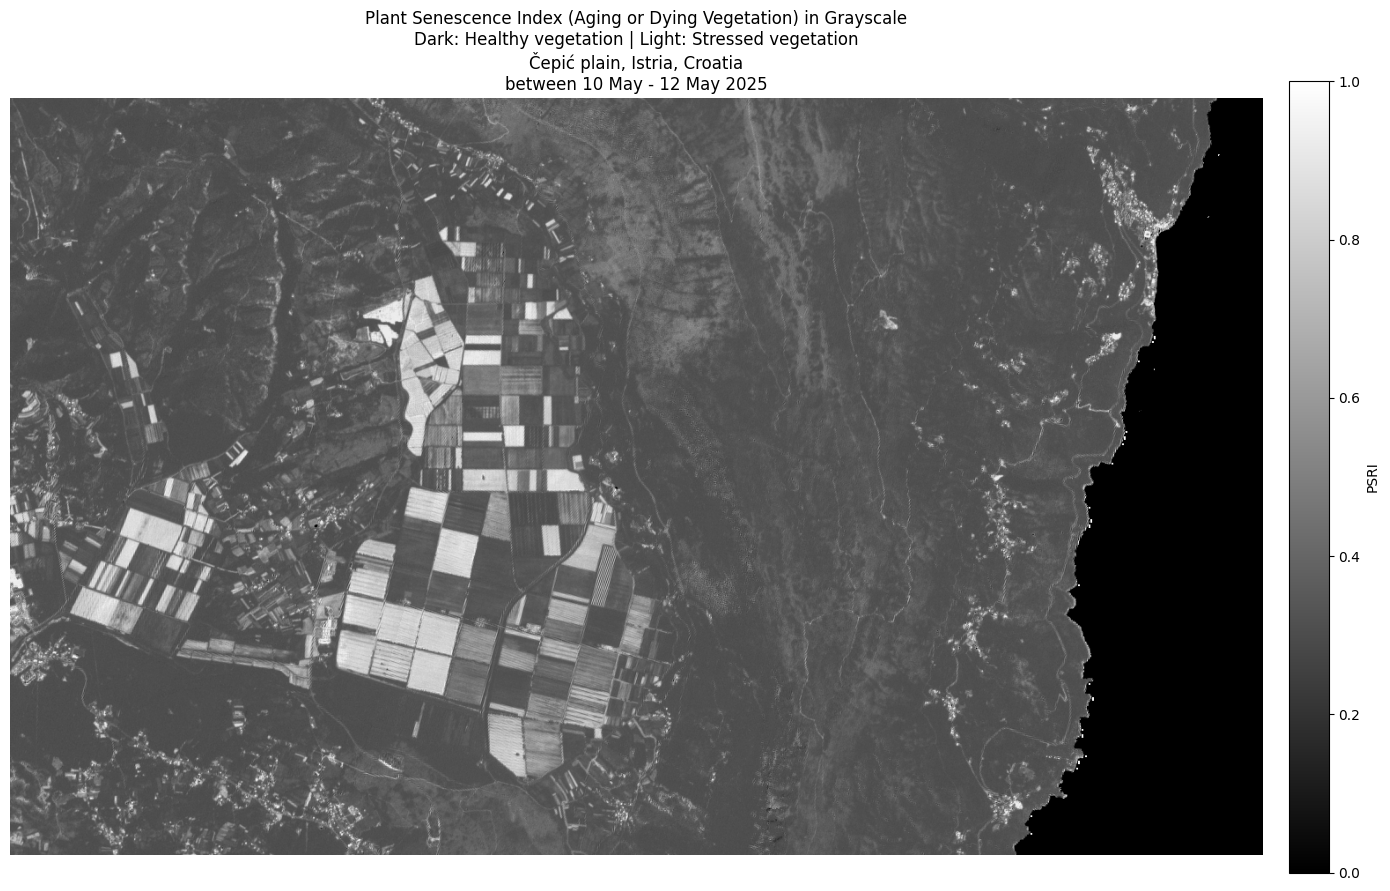

In [15]:
# Load and display the image
img = Image.open("psri_image.png").convert("L")
arr = np.array(img) / 255.0

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
im = ax.imshow(arr, cmap="gray", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="PSRI", fraction=0.03, pad=0.02)
ax.set_title(
    "Plant Senescence Index (Aging or Dying Vegetation) in Grayscale\n"
    "Dark: Healthy vegetation | Light: Stressed vegetation\n"
    "Čepić plain, Istria, Croatia\n"
    "between 10 May - 12 May 2025",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

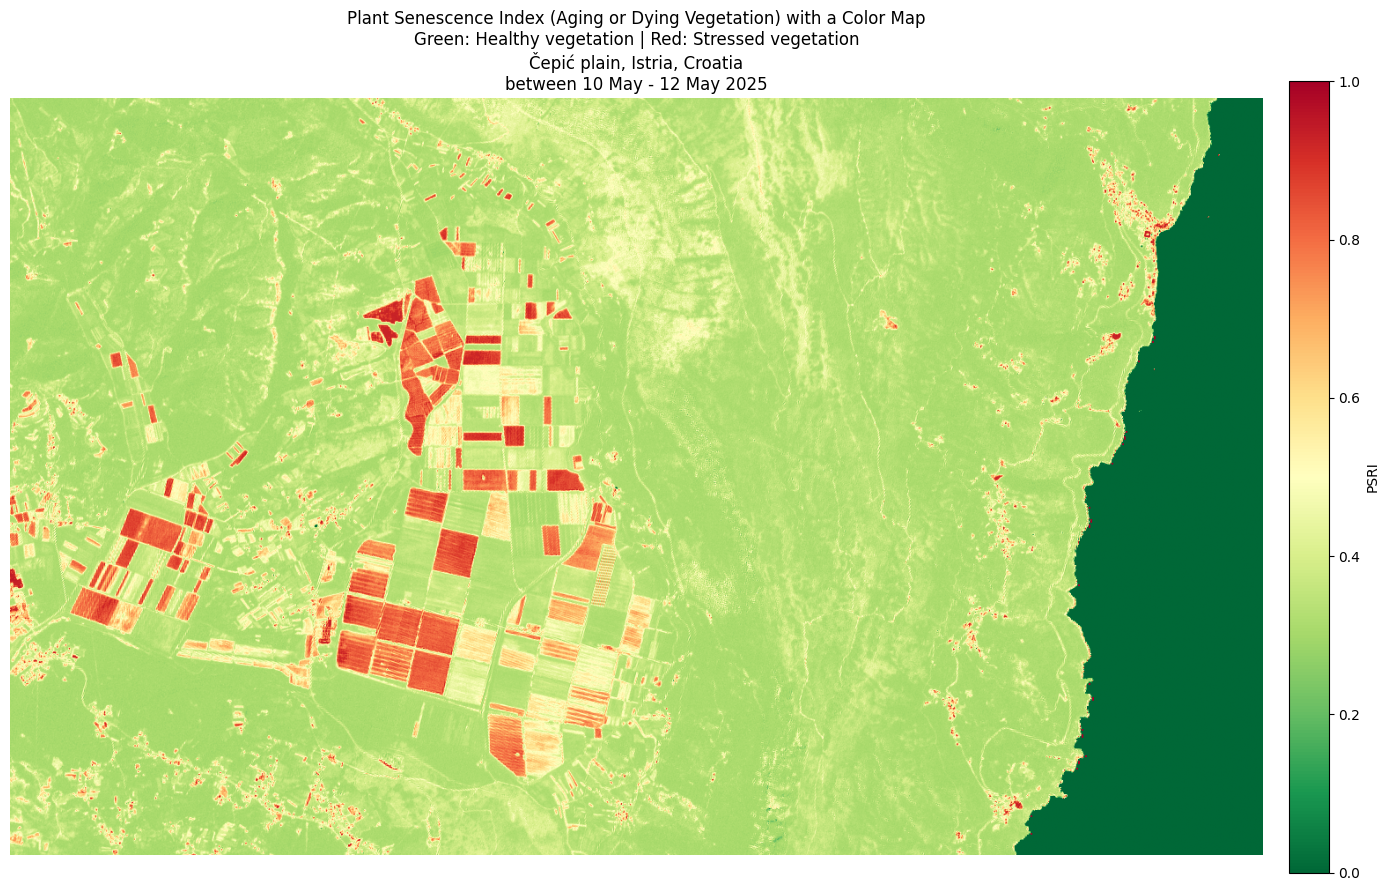

In [16]:
# Load and display the image
img = Image.open("psri_image.png").convert("L")
arr = np.array(img) / 255.0

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
im = ax.imshow(arr, cmap="RdYlGn_r", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="PSRI", fraction=0.03, pad=0.02)
ax.set_title(
    "Plant Senescence Index (Aging or Dying Vegetation) with a Color Map\n"
    "Green: Healthy vegetation | Red: Stressed vegetation\n"
    "Čepić plain, Istria, Croatia\n"
    "between 10 May - 12 May 2025",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Applications
- Monitoring crop health and growth stages throughout agricultural season
- Detecting early signs of vegetation stress before they become visible to the naked eye
- Tracking seasonal and inter-annual changes in vegetation greenness

## Limitations
- Water surface can be falsely detected as healthy vegetation as the values could fall in the darker side of the color map. It would be good to mask non-vegetated areas as the pre-processing step.

## Citation
The IDB Project. (2026). *Index: Plant Senescence Reflectance Index*. IndexDatabase. https://www.indexdatabase.de/db/i-single.php?id=69

## Attribution

This openEO User-Defined Process is a conversion of the original Sentinel Hub evalscript:

**Original Script**: [Plant Senescence Reflectance Index (PSRI)](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/psri/)

**Author**: (Author is not listed in the original script)

**Source Repository**: [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

This conversion maintains the scientific methodology and visualization approach of the original evalscript while adapting it to the openEO process graph framework for interoperability across openEO-compliant backends.